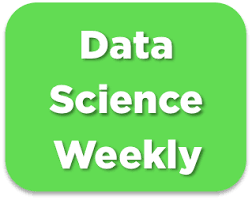

# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, recall_score,precision_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


# Read file with labels

In [2]:
data = pd.read_csv('../data/conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [3]:
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [4]:
data.isna().sum()

country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

# Explore dataset

In [5]:
# The dataset is quite big : you must create a sample of the dataset before making any visualizations !
data_sample = data.sample(10000)

# Make your model

## Choose variables to use in the model, and create train and test sets
**From the EDA, we know that the most useful feature is total_pages_visited. Let's create a baseline model by using at first only this feature : in the next cells, we'll make preprocessings and train a simple (univariate) logistic regression.**

In [6]:
# Divide dataset Train set & Test set 

target = 'converted'

x = data.drop(target, axis=1)
y = data[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## Training pipeline

In [7]:
# Put here all the preprocessings
numerical_features = x.select_dtypes(exclude='object').columns.tolist()
categorical_features = x.select_dtypes(include='object').columns.tolist()

encoder = OneHotEncoder(drop='first')
scaler = StandardScaler()

categorical_pipeline = Pipeline(
    steps=[
        ('cat_encoder', encoder)
    ]
)

numerical_pipeline = Pipeline(
    steps=[
        ('num_scaler', scaler)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_col', numerical_pipeline, numerical_features),
        ('cat_col', categorical_pipeline, categorical_features)
    ]
)


In [8]:
classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression())
    ]
)

classifier.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_col', ...), ('cat_col', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Test pipeline

In [9]:
y_train_pred = classifier.predict(x_train)
y_test_pred = classifier.predict(x_test)

## Performance assessment

In [10]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(y_train, y_train_pred))
print("f1-score on test set : ", f1_score(y_test, y_test_pred))
print()

print("accuracy on training set : ", accuracy_score(y_train, y_train_pred))
print("accuracy on test set : ", accuracy_score(y_test, y_test_pred))
print()

print("recall-score on training set: ", recall_score(y_train, y_train_pred))
print("recall-score on training set: ", recall_score(y_test, y_test_pred))
print()

print("precision-score on training set: ", precision_score(y_train, y_train_pred))
print("precision-score on test set: ", precision_score(y_test, y_test_pred))

f1-score on train set :  0.7620197750773643
f1-score on test set :  0.767505304637769

accuracy on training set :  0.9861506430529201
accuracy on test set :  0.986524000281116

recall-score on training set:  0.6873638344226579
recall-score on training set:  0.6895424836601307

precision-score on training set:  0.8548687552921254
precision-score on test set:  0.8653451811346549


In [11]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(y_train, y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(y_test, y_test_pred))
print()

Confusion matrix on train set : 
[[219463    857]
 [  2296   5048]]

Confusion matrix on test set : 
[[54883   197]
 [  570  1266]]



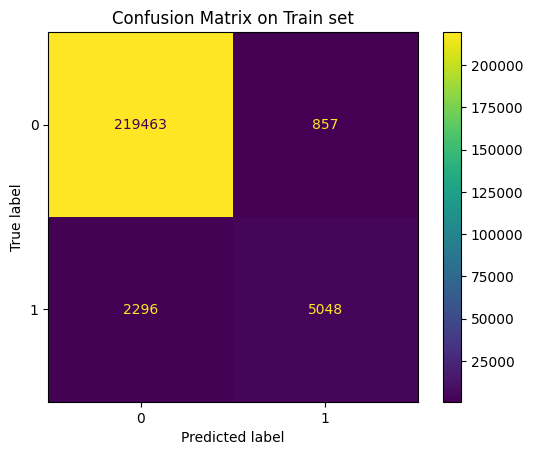

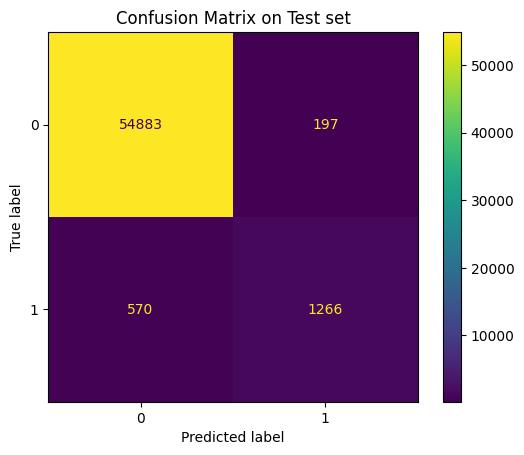

In [12]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, x_train, y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

# Confusion Matrix
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, x_test, y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

Train and test F1-scores are very close, indicating that the model generalizes well and does not show signs of overfitting.  
On the test set, the model shows high precision but still misses a significant number of actual converters (false negatives), resulting in a moderate recall.  
Since the F1-score is the harmonic mean of precision and recall, this lower recall directly limits the F1-score. Improving recall by reducing false negatives would therefore increase the F1-score, as long as precision remains reasonably stable.

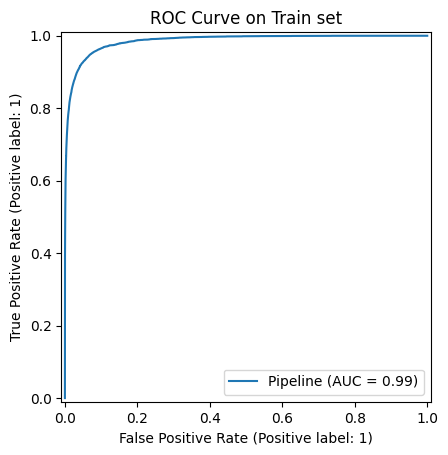

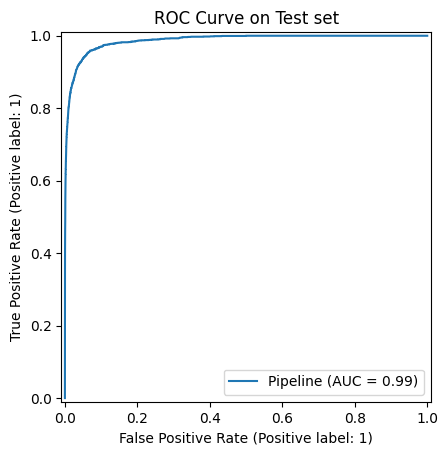

In [13]:
# RocCurve
_, ax = plt.subplots()  
ax.set(
    title="ROC Curve on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    classifier, x_train, y_train, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="ROC Curve on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    classifier, x_test, y_test, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()

The ROC–AUC score indicates that the model is able to correctly rank converted users higher than non-converted ones.  
However, in this highly imbalanced setting, a good ROC–AUC does not necessarily translate into a high F1-score, as it does not account for the chosen decision threshold. This explains why the model can achieve a strong ROC–AUC while still missing a significant number of actual converters.

In [14]:
# Analyze the model's coefficients.
column_names = classifier.named_steps['preprocessor'].get_feature_names_out().tolist()  
print("Names of columns corresponding to each coefficient: ", column_names)
# Create a pandas DataFrame
coefs = pd.DataFrame(index = column_names, 
                     data = classifier.named_steps["classifier"].coef_[0].transpose(), 
                     columns=["coefficients"])
coefs
# Compute abs() and sort values
feature_importance = abs(coefs).sort_values(by = 'coefficients')
feature_importance
# Plot coefficients
fig = px.bar(feature_importance, orientation = 'h')
fig.update_layout(showlegend = False, 
                  margin = {'l': 120} # to avoid cropping of column names
                 )
print(coefs.sort_values(by="coefficients", axis=0, ascending=False))
fig.show()

Names of columns corresponding to each coefficient:  ['num_col__age', 'num_col__new_user', 'num_col__total_pages_visited', 'cat_col__country_Germany', 'cat_col__country_UK', 'cat_col__country_US', 'cat_col__source_Direct', 'cat_col__source_Seo']
                              coefficients
cat_col__country_Germany          3.568165
cat_col__country_UK               3.398430
cat_col__country_US               3.061020
num_col__total_pages_visited      2.525067
cat_col__source_Seo              -0.041889
cat_col__source_Direct           -0.211101
num_col__age                     -0.599194
num_col__new_user                -0.785277


The coefficient analysis is fully consistent with the exploratory data analysis. In particular, total pages visited, previously identified in the EDA as the strongest behavioral indicator of conversion, appears as one of the most influential features in the model. The model also clearly learns country-level conversion patterns: only countries associated with relatively high conversion rates receive strong positive coefficients. Conversely, countries with very low conversion rates, such as China, do not appear among the most influential features, indicating that the model effectively downweights markets with limited conversion potential.
Germany stands out as a country with relatively low traffic volume but a high conversion propensity, a pattern highlighted during the EDA and effectively captured by the model through a strong positive coefficient.

These results suggest that the model captures meaningful behavioral and geographical signals but remains conservative in its predictions, as reflected by its moderate recall. In the next steps, we explore ways to improve the model’s ability to detect more actual converters, with the objective of increasing recall and therefore the F1-score, while keeping precision under control.

**Our baseline model reaches a f1-score of almost 70%. Now, feel free to refine your model and try to beat this score ! 🚀🚀**

# Train best classifier on all data and use it to make predictions on X_without_labels
**Before making predictions on the file conversion_data_test.csv, let's train our model on ALL the data that was in conversion_data_train.csv. Sometimes, this allows to make tiny improvements in the score because we're using more examples to train the model.**

In [15]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = pd.concat([x_train, x_test], axis=0, ignore_index=True)
Y = pd.concat([y_train, y_test], axis=0, ignore_index=True)
classifier.fit(X,Y)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_col', ...), ('cat_col', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
# Read data without labels
data_without_labels = pd.read_csv('../data/conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features 
# used by your best classifier)
# features_list = ['total_pages_visited']
# X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
# print("Convert pandas DataFrames to arrays...")
# X_without_labels = X_without_labels.values
# print("...Done")

# print(X_without_labels[0:5,:])

Prediction set (without labels) : (31620, 5)


In [17]:
# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
# print("Encoding categorical features and standardizing numerical features...")

# X_without_labels = preprocessor.transform(data_without_labels)
# print("...Done")
# print(X_without_labels[0:5,:])

In [18]:
# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
X_without_labels = data_without_labels
data = {
    'converted': classifier.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('../result/conversion_data_test_predictions_Olivier-logreg.csv', index=False)


## Analyzing the coefficients and interpreting the result
**In this template, we just trained a model with only one feature (total_pages_visited), so there's no analysis to be done about the feature importance 🤔**

**Once you've included more features in your model, please take some time to analyze the model's parameters and try to find some lever for action to improve the newsletter's conversion rate 😎😎**